# Generating surrogate data for inference
There are many ways to generate surrogate data for inference. Here we introduce and compare several methods.

In [2]:
import pickle as pkl
from scipy.stats import sem
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

from pyriodic.preproc import RawSignal, Pipeline
from pyriodic.surrogate import surrogate_shuffle_breath_cycles, surrogate_time_shifted, surrogate_random, surrogate_iaaft, extract_phase_angles_surrogate_ts
from pyriodic.viz import plot_phase_diagnostics

from pyriodic.datasets import sample

In [3]:
preproc_pipeline = (
    Pipeline() \
    .add(RawSignal.filter_bandpass , low=0.1, high=1.0) \
    .add(RawSignal.smoothing, window_size=500) \
    .add(RawSignal.zscore) \
)

In [4]:
path = sample.data_path() 

with open(path, "rb") as f:
    data = pkl.load(f)

resp_ts, sfreq, behav_data = data["resp_ts"], data["sfreq"], data["behav_data"]
event_samples, event_ids, labels= behav_data["event_samples"], behav_data["event_ids"], behav_data["event_type"]

In [5]:
# # only keep 4 minutes of data
start_sample = event_samples[0]
n_samples = int(sfreq * 60 * 4)
resp_ts = resp_ts[start_sample:start_sample+n_samples]

# remove rejected indices from the the event samples
event_samples = [event-start_sample for event in event_samples]
target_event_samples = [
    samp for samp, label in zip(event_samples, labels) if "target" in label
]

# check that they are below the length of the raw signal
target_event_samples = [samp for samp in target_event_samples if samp < len(resp_ts)]


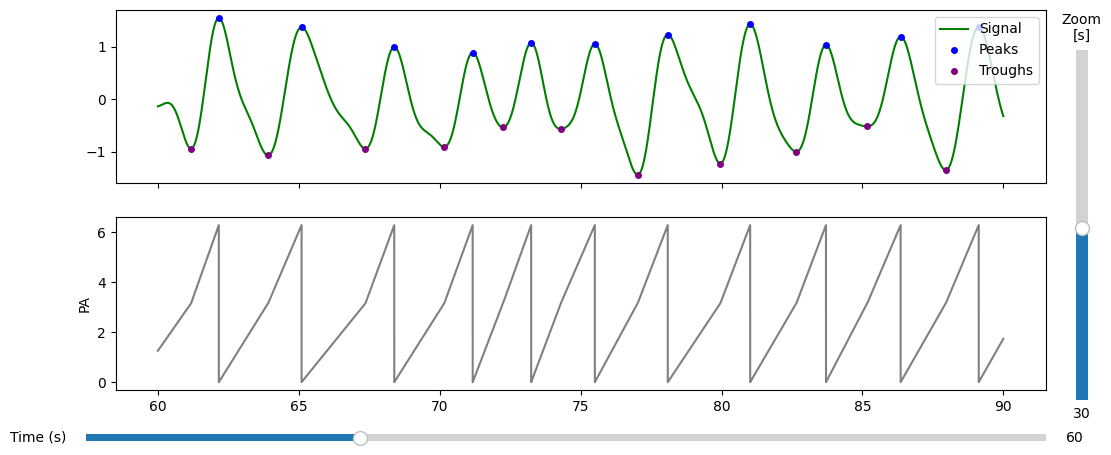

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: >, <Axes: ylabel='PA'>], dtype=object))

In [8]:
raw = RawSignal(resp_ts, sfreq)

# apply preprocessing pipeline
raw = preproc_pipeline.apply(raw)

PA, peaks, troughs = raw.phase_twopoint(prominence=0.1)

plot_phase_diagnostics(
    {"PA": PA},
    start = 60,
    window_duration = 30,
    fs = raw.fs,
    data = raw.ts,
    peaks=peaks, # plotting the peaks and troughs from the two-point method. Same peaks are identified by the one-point method. 
    troughs=troughs 
)

# Comparing different methods



In [9]:
surrogate_methods = [surrogate_iaaft, surrogate_shuffle_breath_cycles, surrogate_time_shifted, surrogate_random]
n_surrogates = 200

surrogates = {}

for surrogate_method in surrogate_methods:
    method_name = surrogate_method.__name__ + "()"
    print(f"Extracting phase angles from surrogate data using method: {method_name}")
    if surrogate_method == surrogate_iaaft:
        surr_ts = surrogate_iaaft(resp_ts, n_surrogate=n_surrogates, verbose=True)
            
        surrogate_phase_angles, surrogate_phase_ts = extract_phase_angles_surrogate_ts(
            surr_ts, 
            target_event_samples, 
            preproc_pipeline=preproc_pipeline, 
            fs=sfreq, 
            return_phase_ts=True
        )
        surrogates[method_name] = (surrogate_phase_angles, surrogate_phase_ts)
    else:
        surrogate_phase_angles, surrogate_phase_ts = surrogate_method(
            phase_pool=PA,
            events=target_event_samples,    
            return_ts=True,
            n_surrogate=n_surrogates,
        )
        surrogates[method_name] = (surrogate_phase_angles, surrogate_phase_ts)

Extracting phase angles from surrogate data using method: surrogate_iaaft()


Estim100%|██████████████████████████████| 200/200 [33:05<00:00,  9.93s/it]


Extracting phase angles from surrogate data using method: surrogate_shuffle_breath_cycles()


100%|██████████| 200/200 [00:00<00:00, 1278.01it/s]

Generated 200 surrogate time series by shuffling breathing cycles.
Extracting phase angles from surrogate data using method: surrogate_time_shifted()
Generating null samples with time shifts...


Extracting phase angles from surrogate data using method: surrogate_random()


In [10]:
def circular_autocorr(phases, lag):
    z1 = np.exp(1j * phases[:-lag])
    z2 = np.exp(1j * phases[lag:])
    return np.real(np.nanmean(z1 * np.conj(z2)))

In [11]:
dat_for_plot = {}

lags_sec = np.arange(0, 10, 0.1)
lags = (lags_sec * raw.fs).astype(int)

# -------- ORIGINAL --------
autocorrs = []
for lag in lags:
    if lag == 0:
        autocorrs.append(1)
    else:
        autocorrs.append(circular_autocorr(PA, lag))

dat_for_plot["original"] = (lags_sec, np.array(autocorrs), None, None)


# -------- SURROGATES --------
for method_name, (surrogate_phase_angles, surrogate_phase_ts) in surrogates.items():
    print(f"Computing autocorrelation for surrogate method: {method_name}")

    mean_ac = []
    sem_ac = []
    std_ac = []

    for lag in tqdm(lags):

        if lag == 0:
            mean_ac.append(1)
            sem_ac.append(0)
            std_ac.append(0)
            continue

        lag_corrs = [
            circular_autocorr(surr, lag)
            for surr in surrogate_phase_ts
        ]

        lag_corrs = np.array(lag_corrs)

        mean_ac.append(np.nanmean(lag_corrs))
        sem_ac.append(sem(lag_corrs, nan_policy='omit'))
        std_ac.append(np.nanstd(lag_corrs))

    dat_for_plot[method_name] = (
        lags_sec,
        np.array(mean_ac),
        np.array(sem_ac),
        np.array(std_ac)
    )


Computing autocorrelation for surrogate method: surrogate_iaaft()


100%|██████████| 100/100 [01:58<00:00,  1.18s/it]


Computing autocorrelation for surrogate method: surrogate_shuffle_breath_cycles()


100%|██████████| 100/100 [01:58<00:00,  1.19s/it]


Computing autocorrelation for surrogate method: surrogate_time_shifted()


100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


Computing autocorrelation for surrogate method: surrogate_random()


100%|██████████| 100/100 [02:29<00:00,  1.50s/it]


In [12]:
plv_for_plot = {}

for method_name, data in surrogates.items():
    print(f"Computing PLV for surrogate method: {method_name}")
    _, surr_PA_ts = data
    plvs = []
    for i, tmp_surr in enumerate(surr_PA_ts):
        tmp_PA = PA.copy()
        # get indices of the surrogate phase angle time series that are nan
        plvs.append (np.abs(np.nanmean(np.exp(1j * (tmp_PA - tmp_surr)))))


    plv_for_plot[method_name] = (plvs, np.mean(plvs), sem(plvs), np.std(plvs))

Computing PLV for surrogate method: surrogate_iaaft()
Computing PLV for surrogate method: surrogate_shuffle_breath_cycles()
Computing PLV for surrogate method: surrogate_time_shifted()
Computing PLV for surrogate method: surrogate_random()


In [13]:
colormap = plt.get_cmap("tab10")
colors = {
    "original": "black",
    "surrogate_shuffle_breath_cycles()": colormap(0),
    "surrogate_time_shifted()": colormap(1),
    "surrogate_random()": colormap(2),
    "surrogate_iaaft()": colormap(3)
}

Plotting autocorrelation for method: original
Plotting autocorrelation for method: surrogate_iaaft()
Plotting autocorrelation for method: surrogate_shuffle_breath_cycles()
Plotting autocorrelation for method: surrogate_time_shifted()
Plotting autocorrelation for method: surrogate_random()


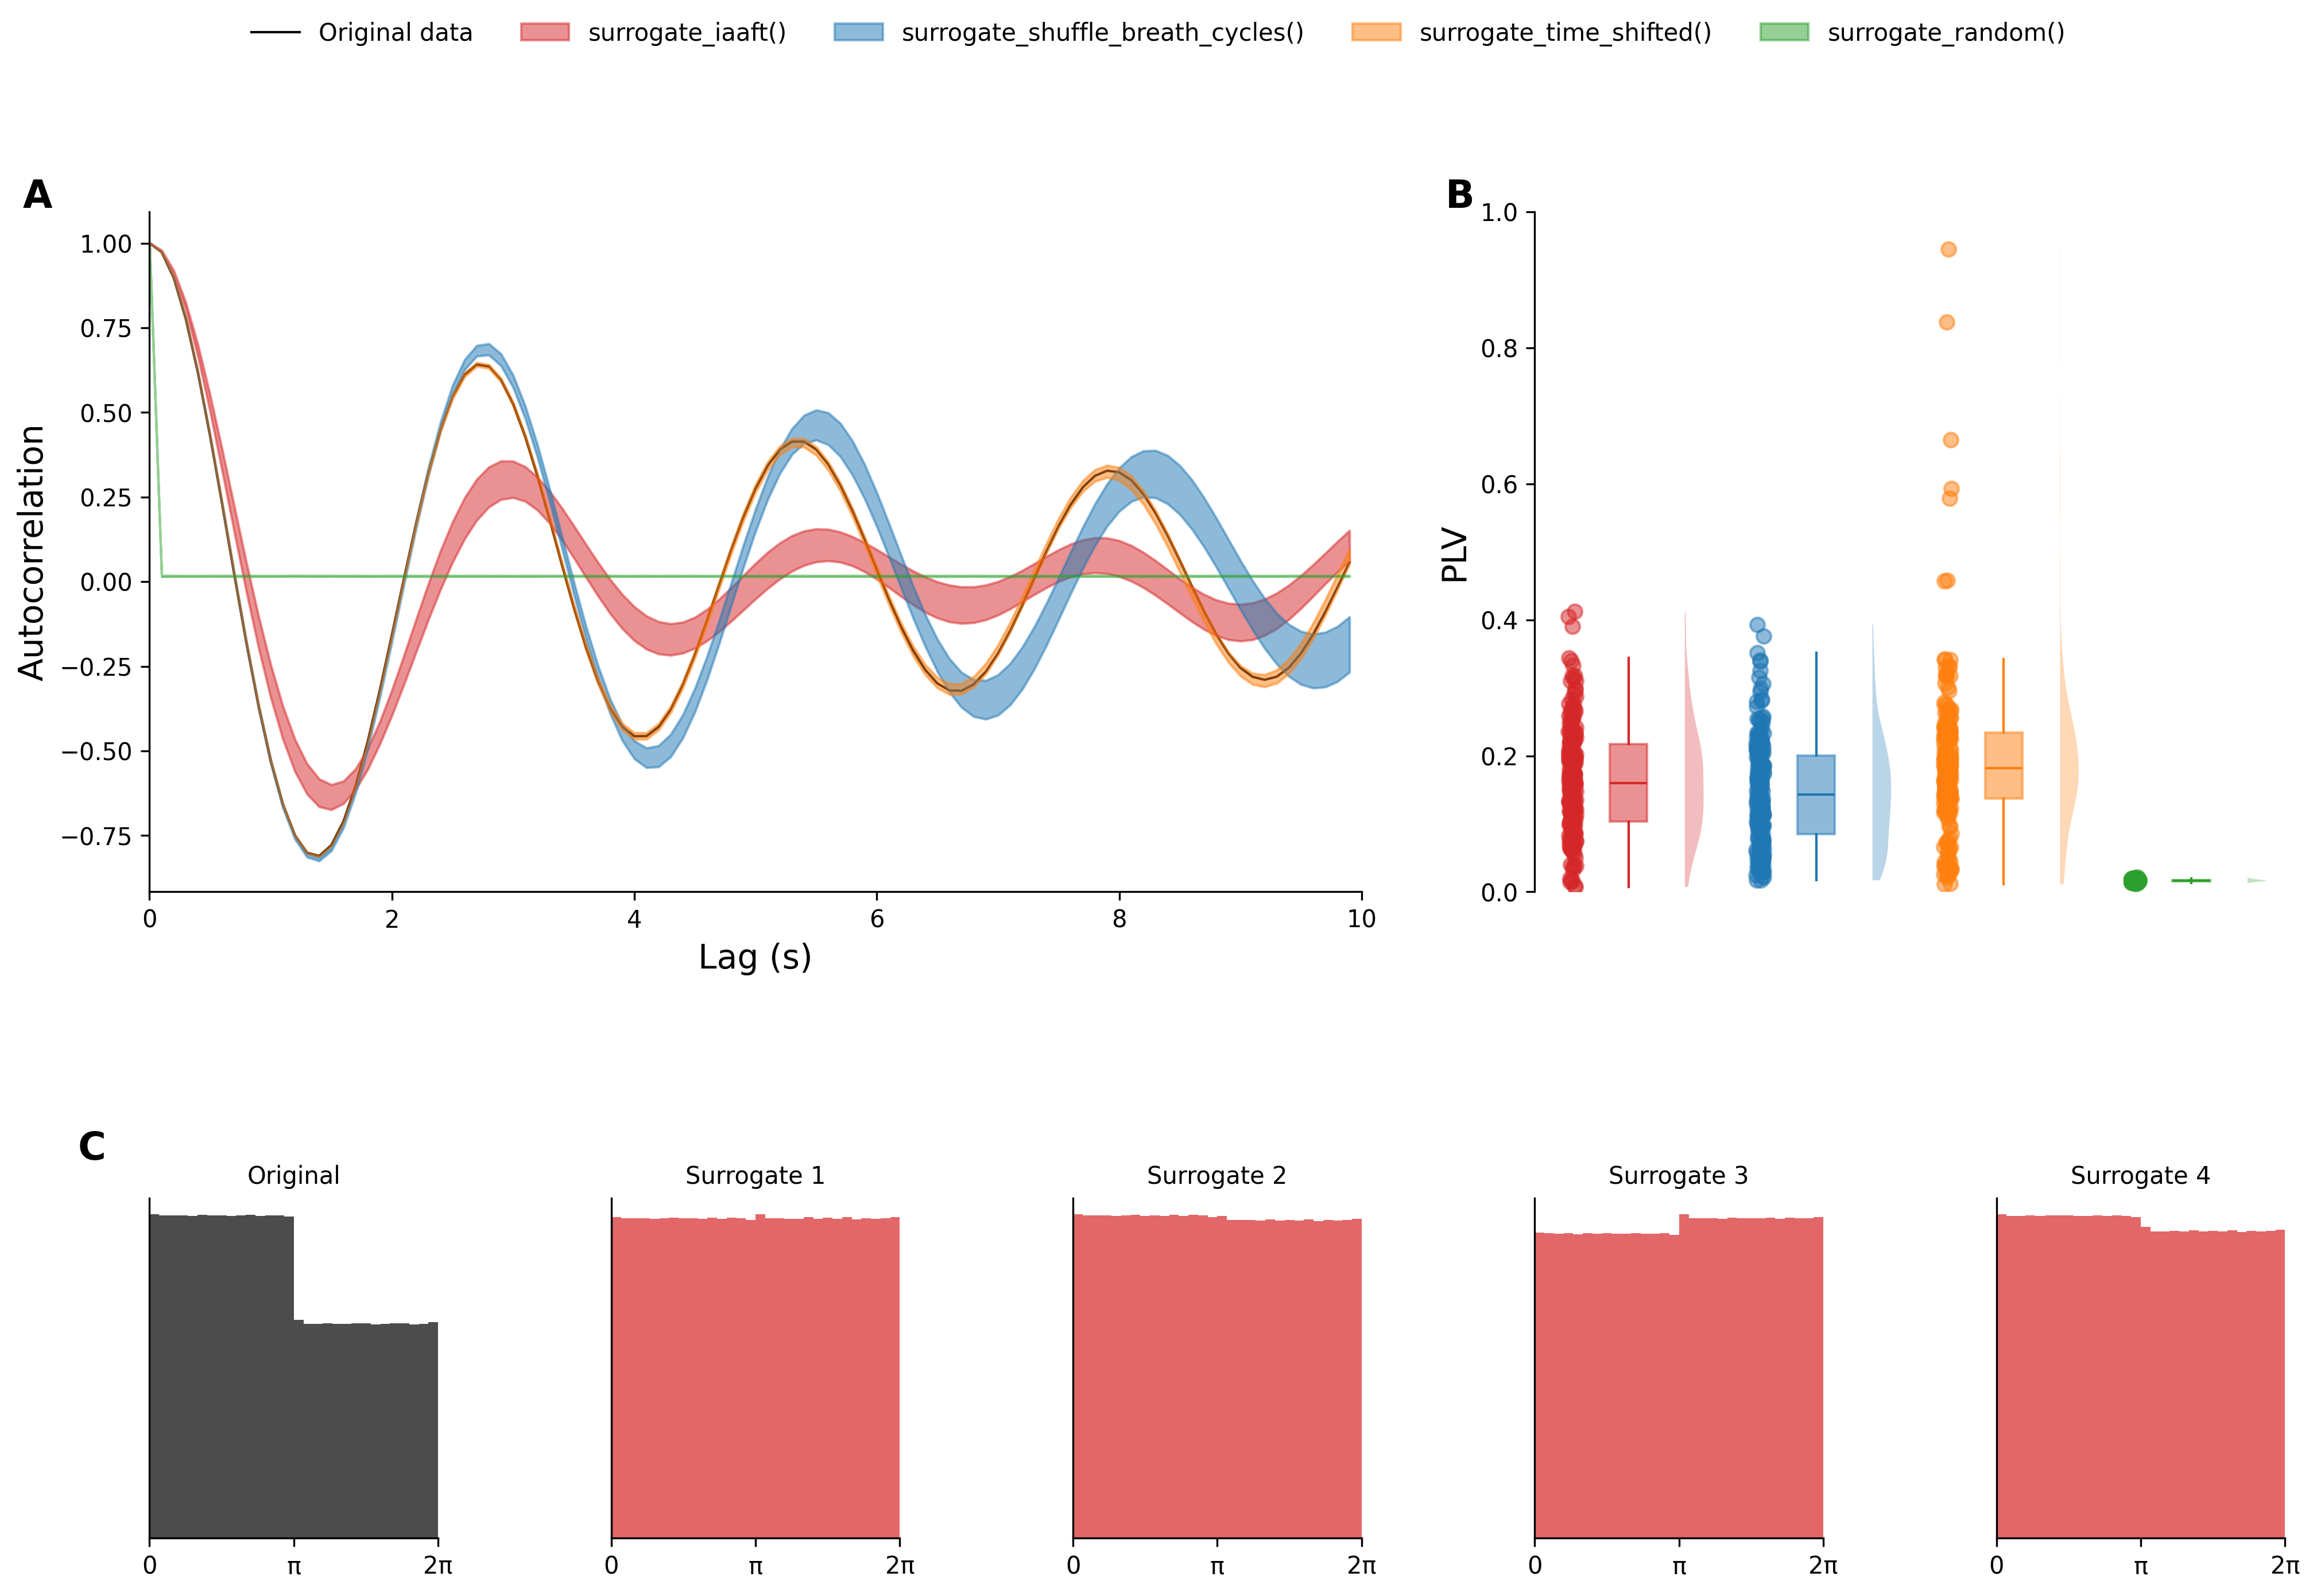

In [14]:
fig = plt.figure(figsize=(16, 10), dpi=300)

n_histograms = 5  # number of surrogate histograms to plot
gs = gridspec.GridSpec(
    nrows=2,
    ncols=n_histograms,
    figure=fig,
    width_ratios=[1] * n_histograms,
    height_ratios=[2, 1],
    hspace=0.6, 
    wspace=0.6
)

# Top row
ax_ac = fig.add_subplot(gs[0, :3])
ax_plv = fig.add_subplot(gs[0, 3:])

# Bottom row: one histogram per surrogate
hist_axes = [fig.add_subplot(gs[1, i]) for i in range(n_histograms)]

# =============================================================================
# Autocorrelation plot
# =============================================================================

for method_name, data in dat_for_plot.items():

    lags_sec = data[0]
    mean_ac = data[1]
    sem_ac = data[2]
    std_ac = data[3]

    print(f"Plotting autocorrelation for method: {method_name}")

    if method_name == "original":
        z_order = 1
        color = "black"
        linewidth = 1
        alpha = 1

        ax_ac.plot(
            lags_sec,
            mean_ac,
            label="Original data",
            color=color,
            linewidth=linewidth,
            zorder=z_order,
            alpha=alpha,
        )

    else:
        # avoid plotting artefacts at lag 0
        sem_ac[0] = sem_ac[1]
        std_ac[0] = std_ac[1]

        z_order = 0
        color = colors[method_name]
        alpha = 0.5

        ax_ac.fill_between(
            lags_sec,
            mean_ac - std_ac,
            mean_ac + std_ac,
            alpha=alpha,
            label=method_name,
            color=color,
        )

ax_ac.set_xlabel("Lag (s)")
ax_ac.set_ylabel("Autocorrelation")
ax_ac.set_xlim([0, 10])

# =============================================================================
# PLV plot
# =============================================================================

alpha = 0.5

for method_name, data in plv_for_plot.items():

    if method_name == "original":
        continue

    color = colors[method_name]

    box_plot_pos = [list(plv_for_plot.keys()).index(method_name)]
    scatter_pos_x = box_plot_pos[0] - 0.3
    violin_pos = box_plot_pos[0] + 0.3

    # -------------------------------------------------------------------------
    # Scatter
    # -------------------------------------------------------------------------

    x_offset = 0.02
    x = [scatter_pos_x] * len(data[0])
    x = [xi + np.random.uniform(-x_offset, x_offset) for xi in x]

    ax_plv.scatter(
        x,
        data[0],
        alpha=alpha,
        color=color,
    )

    # -------------------------------------------------------------------------
    # Boxplot
    # -------------------------------------------------------------------------

    ax_plv.boxplot(
        data[0],
        positions=box_plot_pos,
        widths=0.2,
        patch_artist=True,
        showmeans=False,
        meanline=False,
        showcaps=False,
        showfliers=False,
        medianprops=dict(color=color),
        boxprops=dict(
            facecolor=color,
            color=color,
            alpha=alpha,
        ),
        whiskerprops=dict(color=color),
    )

    # -------------------------------------------------------------------------
    # Violin
    # -------------------------------------------------------------------------

    vplot = ax_plv.violinplot(
        data[0],
        positions=[violin_pos],
        widths=0.2,
        showmeans=False,
        showextrema=False,
        showmedians=False,
        side="high",
    )

    vplot["bodies"][0].set_facecolor(color)

ax_plv.set_ylabel("PLV")
ax_plv.set_ylim([0, 1])
ax_plv.set_xticks([])
ax_plv.spines["bottom"].set_visible(False)

# =============================================================================
# Surrogate phase-angle histograms
# =============================================================================

hist_method = "surrogate_iaaft()"  # <-- change if desired

_, surr_PA_ts = surrogates[hist_method]




for i, ax in enumerate(hist_axes):
    if i == 0:
        ax.set_title("Original", fontsize=10)

        ax.hist(
            PA,
            bins=30,
            density=True,
            color=colors["original"],
            alpha=0.7,
        )

    else:
        ax.set_title(f"Surrogate {i}", fontsize=10)

        ax.hist(
            surr_PA_ts[i-1],
            bins=30,
            density=True,
            color=colors[hist_method],
            alpha=0.7,
        )


    ax.set_xlim([0, 2*np.pi])
    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels(["0", "π", "2π"])
    ax.set_yticks([])

# =============================================================================
# Styling
# =============================================================================

all_axes = [ax_ac, ax_plv] + hist_axes

for ax in all_axes:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.yaxis.label.set_size(14)
    ax.xaxis.label.set_size(14)

# =============================================================================
# Shared legend
# =============================================================================

handles, labels = ax_ac.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False,
)

ax_ac.text(
    -0.08, 1.05, "A",
    transform=ax_ac.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="right",
)

ax_plv.text(
    -0.08, 1.05, "B",
    transform=ax_plv.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="right",
)

hist_axes[0].text(
    -0.15, 1.2, "C",
    transform=hist_axes[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="right",
)

#plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()